In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"../data/student-mat.csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
# Kiểm tra dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
# Thống kê cơ bản
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [7]:
# Kiểm tra missing values
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


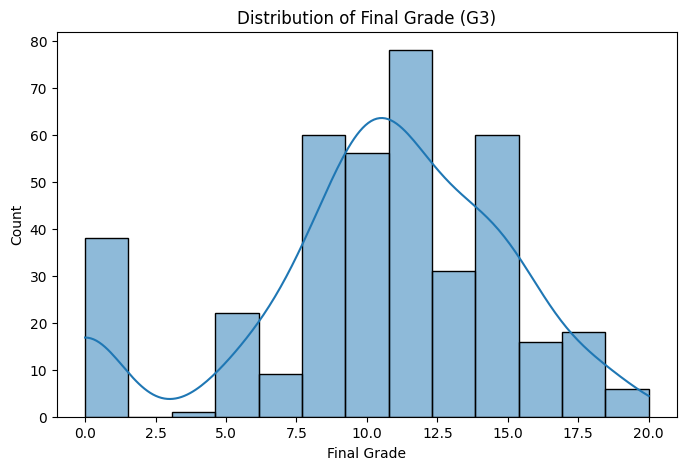

In [10]:
# Biểu đồ 1: Phân tích điểm cuối kỳ (Biến mục tiêu)
plt.figure(figsize=(8,5))
sns.histplot(df["G3"], kde=True)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Count")

plt.show()

Nhận xét: Phần lớn học sinh có điểm nằm trong khoảng 8-15.Khá nhiều học sinh 0-1.


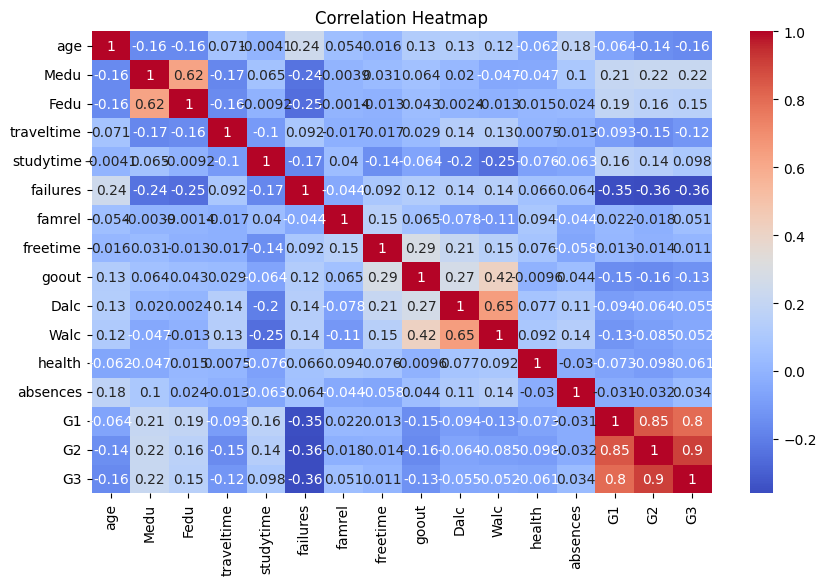

In [11]:
# Biểu đồ 2: Phân tích tương quan giữa các biến
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

Nhận xét: Các biến G1 và G2 ảnh hưởng lớn tới G3. Biến failures cho thấy học sinh từng rớt có xu hướng điểm thấp hơn.
Trình độ cha mẹ ảnh hưởng lớn đến học sinh

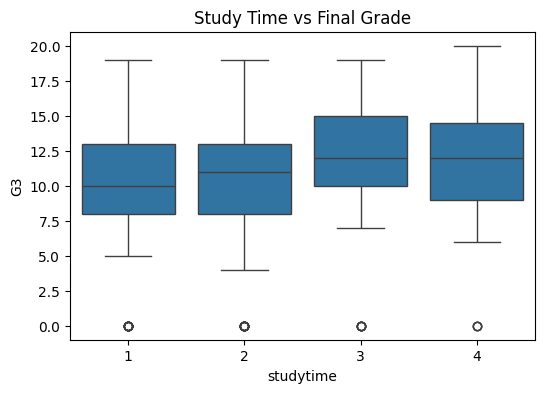

In [12]:
# Biểu đồ 4: Ảnh hưởng của thời gian học
plt.figure(figsize=(6,4))
sns.boxplot(x="studytime", y="G3", data=df)

plt.title("Study Time vs Final Grade")
plt.show()

Nhận xét: Những học sinh có study time cao hơn thường đạt điểm trung bình cao hơn.
Tuy nhiên sự khác biệt giữa các nhóm không quá lớn, cho thấy còn nhiều yếu tố khác ảnh hưởng đến kết quả học tập.

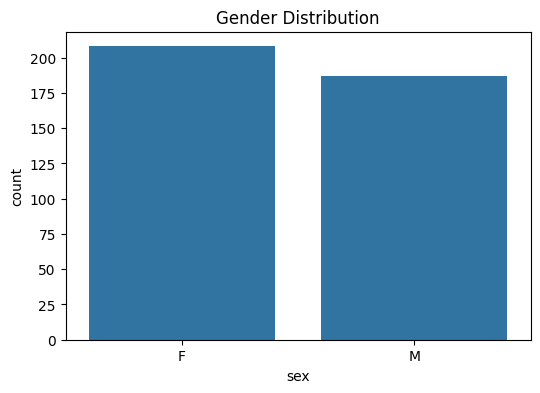

In [14]:
# Biểu đồ 5: Phân bố giới tính
plt.figure(figsize=(6,4))
sns.countplot(x="sex", data=df)

plt.title("Gender Distribution")
plt.show()

Nhận xét:  Data xét có sự phân bố giới tính khá cân bằng

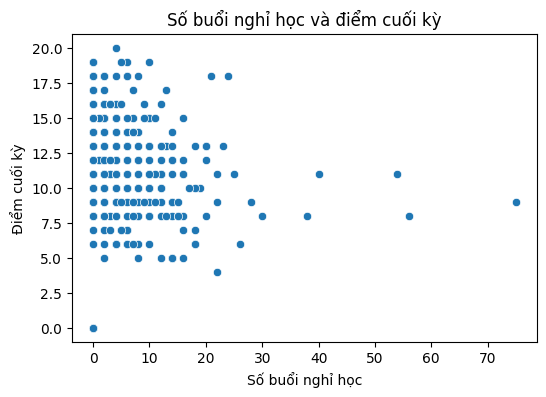

In [19]:
# Biểu đồ 6: số buổi nghỉ học và điểm cuối kỳ
plt.figure(figsize=(6,4))

sns.scatterplot(x="absences", y="G3", data=df)

plt.title("Số buổi nghỉ học và điểm cuối kỳ")

plt.xlabel("Số buổi nghỉ học")
plt.ylabel("Điểm cuối kỳ")

plt.show()

Nhận xét: Có xu hướng điểm số giảm khi số buổi nghỉ học tăng

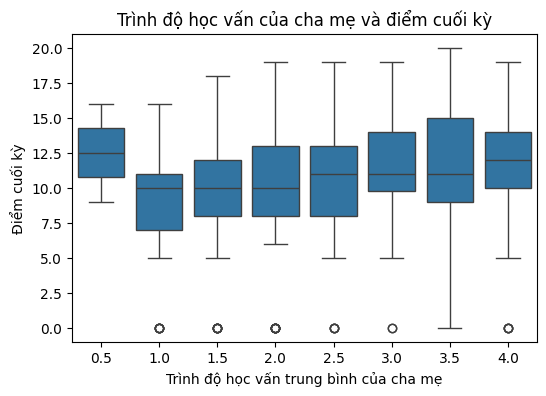

In [20]:
# Biểu đồ 7: trình độ học vấn của cha mẹ và điểm cuối kỳ
df["parent_edu"] = (df["Medu"] + df["Fedu"]) / 2

plt.figure(figsize=(6,4))

sns.boxplot(x="parent_edu", y="G3", data=df)

plt.title("Trình độ học vấn của cha mẹ và điểm cuối kỳ")

plt.xlabel("Trình độ học vấn trung bình của cha mẹ")
plt.ylabel("Điểm cuối kỳ")

plt.show()

Nhận xét: Khi trình độ học vấn của cha mẹ tăng, điểm số của học sinh có xu hướng tăng nhưng đặc biệt trình độ cha mẹ rất thấp điểm số lại khá cao cho thấy sự nổ lực của học sinh vì cha mẹ

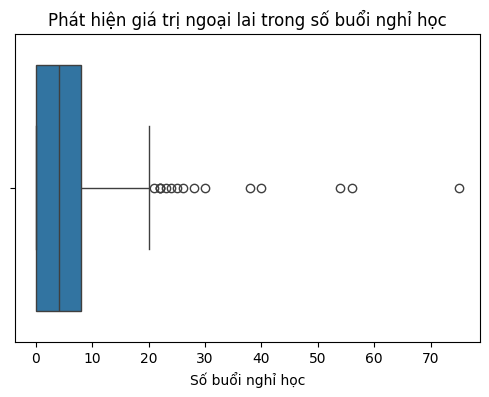

In [22]:
# Biểu đồ 8: Phát hiện giá trị ngoại lai trong số buổi nghỉ học
plt.figure(figsize=(6,4))

sns.boxplot(x=df["absences"])

plt.title("Phát hiện giá trị ngoại lai trong số buổi nghỉ học")

plt.xlabel("Số buổi nghỉ học")

plt.show()

Nhận xét: Có một số học sinh có số buổi nghỉ học rất cao so với phần lớn dữ liệu, những giá trị này có thể được xem là outliers và cần xem xét trong quá trình tiền xử lý dữ liệu